In [3]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [4]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# tamrin

In [3]:
signal, sr = librosa.load('shemo/F01A03.wav', sr=16000)

In [4]:
signal

array([0.00047547, 0.00079437, 0.00070869, ..., 0.00065359, 0.00062604,
       0.00066049], dtype=float32)

In [31]:
sr

16000

In [35]:
len(signal)

100471

In [7]:
input_features = whisper_tiny_processor(
    signal, sampling_rate=sr, return_tensors="pt"
).input_features

In [52]:
input_features[0][0]

tensor(0.0012)

In [12]:
F.softmax(model(input_features).logits)

tensor([[0.3469, 0.2417, 0.2595, 0.1520]], grad_fn=<SoftmaxBackward0>)

# Shemo Loading for Whisper 4 Categories

In [5]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_tiny')

In [6]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger'
}


audios = []
sample_rates = []
emotions = []
labels = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                emotion = 'H' if char == 'W' else char
                # emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))

In [7]:
len(features)

2962

In [8]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample
    

Shemo = AudioDataSet(features, labels)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])


# Example of using DataLoader for batching
train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [9]:
len(trainset), len(valset)

(2462, 500)

In [10]:
len(train_loader), len(val_loader)

(616, 125)

## Train and Test Functions for Whisper

In [11]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [12]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Whisper Tiny

In [13]:
reset_seed(42)
whisper_tiny_path = 'whisper_tiny'
whisper_tiny = WhisperForAudioClassification.from_pretrained(
    whisper_tiny_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.weight', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
reset_seed(42)
for param in whisper_tiny.parameters():
    param.requires_grad = False

for param in whisper_tiny.projector.parameters():
    param.requires_grad = True

whisper_tiny.classifier = torch.nn.Linear(256, 4) # Changing the head to fit our data and problem

In [15]:
whisper_tiny.to(device)

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 384)
    (layers): ModuleList(
      (0-3): 4 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=True)
          (q_proj): Linear(in_features=384, out_features=384, bias=True)
          (out_proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_

In [16]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

training_losses0, valid_losses0 = train(whisper_tiny, 'whisper_tiny_shemo_4cat', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 29.89 seconds, Training Loss:  0.99, Validation Loss: 0.86, Validation Accuracy:  0.68


Epoch: 2 finished in 26.63 seconds, Training Loss:  0.75, Validation Loss: 0.71, Validation Accuracy:  0.75


Epoch: 3 finished in 26.15 seconds, Training Loss:  0.68, Validation Loss: 0.56, Validation Accuracy:  0.79


Epoch: 4 finished in 25.88 seconds, Training Loss:  0.66, Validation Loss: 0.54, Validation Accuracy:  0.80


Epoch: 5 finished in 26.87 seconds, Training Loss:  0.64, Validation Loss: 0.57, Validation Accuracy:  0.81


...

Epoch: 36 finished in 31.80 seconds, Training Loss:  0.48, Validation Loss: 0.64, Validation Accuracy:  0.75


Epoch: 37 finished in 31.61 seconds, Training Loss:  0.48, Validation Loss: 0.48, Validation Accuracy:  0.82


Epoch: 38 finished in 31.64 seconds, Training Loss:  0.48, Validation Loss: 0.47, Validation Accuracy:  0.84


Epoch: 39 finished in 31.42 seconds, Training Loss:  0.48, Validation Loss: 0.47, Validation Accuracy:  0.84


Epoch: 40 finished in 31.59 seconds, Training Loss:  0.46, Validation Loss: 0.45, Validation Accuracy:  0.85
Each epoch took 28.02 seconds in average.


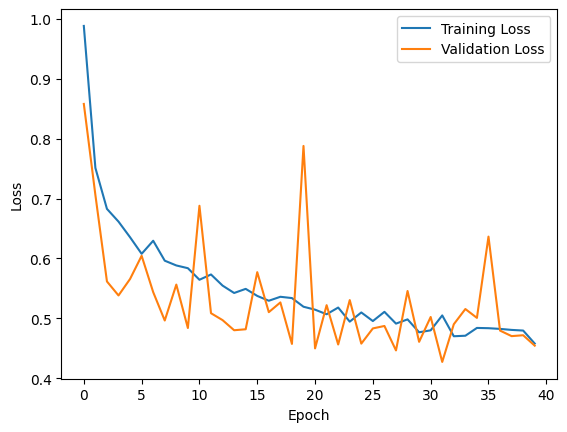

In [17]:
plt.plot(training_losses0, label='Training Loss')
plt.plot(valid_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

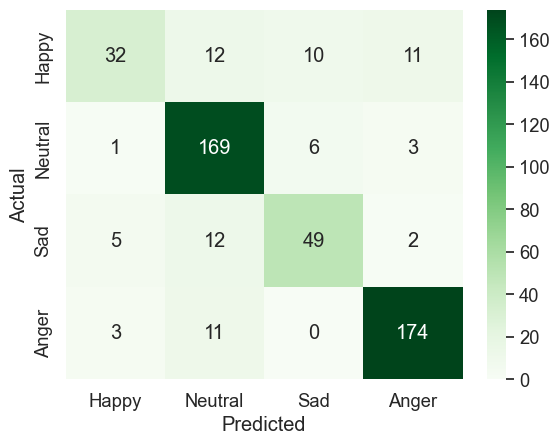

Testing finished with Loss:  0.43 | U_Accuracy:  0.77 | W_Accuracy:  0.85 | Precision:  0.84 | Recall:  0.85 | f1:  0.84
Accuracy per class:
Class 0: 0.49230769230769234
Class 1: 0.9441340782122905
Class 2: 0.7205882352941176
Class 3: 0.925531914893617


In [18]:
whisper_tiny.load_state_dict(torch.load('whisper_tiny_shemo_4cat.bin'))
test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)

# Whisper Small

In [19]:
reset_seed(42)
whisper_small_path = 'whisper_small'
whisper_small = WhisperForAudioClassification.from_pretrained(
    whisper_small_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.projector.weight', 'model.projector.bias', 'model.classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
reset_seed(42)
for param in whisper_small.parameters():
    param.requires_grad = False

for param in whisper_small.projector.parameters():
    param.requires_grad = True

whisper_small.classifier = torch.nn.Linear(256, 4) # Changing the head to fit our data and problem

In [21]:
whisper_small.to(device)

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwis

In [22]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_small.parameters(), lr=0.001)

training_losses1, valid_losses1 = train(whisper_small, 'whisper_small_shemo_4cat', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 133.31 seconds, Training Loss:  0.87, Validation Loss: 0.60, Validation Accuracy:  0.77


Epoch: 2 finished in 132.06 seconds, Training Loss:  0.62, Validation Loss: 0.49, Validation Accuracy:  0.84


Epoch: 3 finished in 131.66 seconds, Training Loss:  0.53, Validation Loss: 0.43, Validation Accuracy:  0.85


Epoch: 4 finished in 132.14 seconds, Training Loss:  0.52, Validation Loss: 0.59, Validation Accuracy:  0.78


Epoch: 5 finished in 132.91 seconds, Training Loss:  0.50, Validation Loss: 0.51, Validation Accuracy:  0.79


...

Epoch: 36 finished in 131.21 seconds, Training Loss:  0.29, Validation Loss: 0.47, Validation Accuracy:  0.86


Epoch: 37 finished in 131.08 seconds, Training Loss:  0.30, Validation Loss: 0.57, Validation Accuracy:  0.83


Epoch: 38 finished in 130.43 seconds, Training Loss:  0.28, Validation Loss: 0.39, Validation Accuracy:  0.87


Epoch: 39 finished in 128.81 seconds, Training Loss:  0.26, Validation Loss: 0.54, Validation Accuracy:  0.80


Epoch: 40 finished in 128.79 seconds, Training Loss:  0.28, Validation Loss: 0.49, Validation Accuracy:  0.81
Each epoch took 131.70 seconds in average.


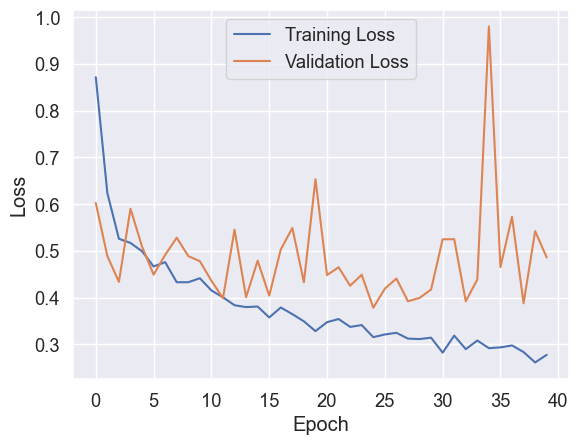

In [23]:
plt.plot(training_losses1, label='Training Loss')
plt.plot(valid_losses1, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

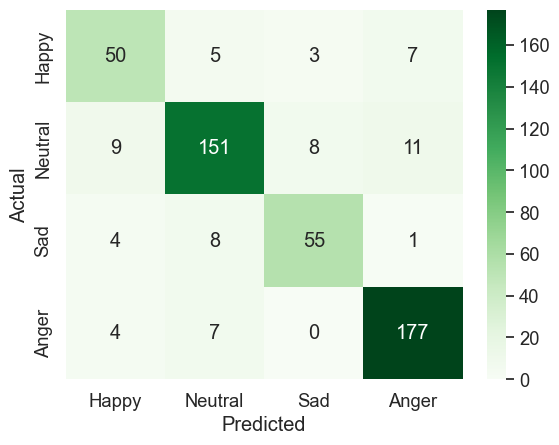

Testing finished with Loss:  0.38 | U_Accuracy:  0.84 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.87
Accuracy per class:
Class 0: 0.7692307692307693
Class 1: 0.8435754189944135
Class 2: 0.8088235294117647
Class 3: 0.9414893617021277


In [25]:
whisper_small.load_state_dict(torch.load('whisper_small_shemo_4cat.bin'))
test(whisper_small, torch.nn.CrossEntropyLoss(), val_loader)

# Whisper Meduim

In [26]:
reset_seed(42)
whisper_medium_path = 'whisper_medium'
whisper_medium = WhisperForAudioClassification.from_pretrained(
    whisper_medium_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.projector.weight', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
reset_seed(42)
for param in whisper_medium.parameters():
    param.requires_grad = False

for param in whisper_medium.projector.parameters():
    param.requires_grad = True

whisper_medium.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

In [28]:
whisper_medium.to(device)

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 1024, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(1024, 1024, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 1024)
    (layers): ModuleList(
      (0-23): 24 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (final_layer_norm): LayerNorm((1024,), eps=1

In [29]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_medium.parameters(), lr=0.001)

training_losses2, valid_losses2 = train(whisper_medium, 'whisper_medium_shemo', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 398.88 seconds, Training Loss:  1.02, Validation Loss: 0.67, Validation Accuracy:  0.77


Epoch: 2 finished in 400.30 seconds, Training Loss:  0.73, Validation Loss: 0.66, Validation Accuracy:  0.77


Epoch: 3 finished in 395.65 seconds, Training Loss:  0.62, Validation Loss: 0.62, Validation Accuracy:  0.78


Epoch: 4 finished in 393.07 seconds, Training Loss:  0.56, Validation Loss: 0.96, Validation Accuracy:  0.65


Epoch: 5 finished in 393.54 seconds, Training Loss:  0.52, Validation Loss: 0.58, Validation Accuracy:  0.82


...

Epoch: 36 finished in 393.26 seconds, Training Loss:  0.26, Validation Loss: 0.47, Validation Accuracy:  0.83


Epoch: 37 finished in 392.42 seconds, Training Loss:  0.28, Validation Loss: 0.44, Validation Accuracy:  0.87


Epoch: 38 finished in 392.37 seconds, Training Loss:  0.27, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 39 finished in 392.51 seconds, Training Loss:  0.28, Validation Loss: 0.57, Validation Accuracy:  0.85


Epoch: 40 finished in 394.18 seconds, Training Loss:  0.26, Validation Loss: 0.63, Validation Accuracy:  0.78
Each epoch took 397.36 seconds in average.


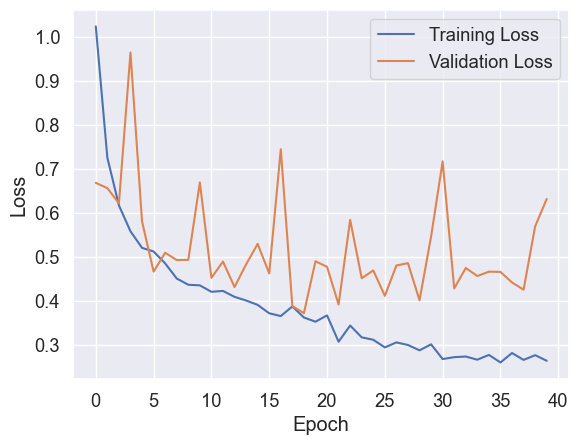

In [30]:
plt.plot(training_losses2, label='Training Loss')
plt.plot(valid_losses2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

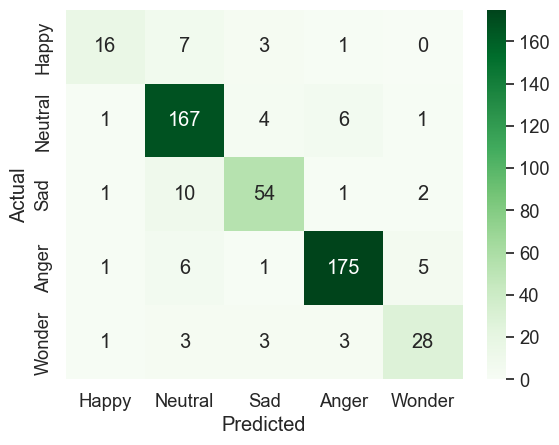

Testing finished with Loss:  0.37 | U_Accuracy:  0.80 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.5925925925925926
Class 1: 0.9329608938547486
Class 2: 0.7941176470588235
Class 3: 0.9308510638297872
Class 4: 0.7368421052631579


In [31]:
whisper_medium.load_state_dict(torch.load('whisper_medium_shemo.bin'))
test(whisper_medium, torch.nn.CrossEntropyLoss(), val_loader)

# Whisper Large V3

In [13]:
reset_seed(42)
whisper_large_path = 'whisper_large_v3'
whisper_large = WhisperForAudioClassification.from_pretrained(
    whisper_large_path
)

Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.46s/it]
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_large_v3 and are newly initialized: ['model.projector.bias', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
reset_seed(42)
for param in whisper_large.parameters():
    param.requires_grad = False

for param in whisper_large.projector.parameters():
    param.requires_grad = True

whisper_large.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

In [15]:
whisper_large.to(device)

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(128, 1280, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(1280, 1280, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 1280)
    (layers): ModuleList(
      (0-31): 32 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
          (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=1280, out_features=5120, bias=True)
        (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        (final_layer_norm): LayerNorm((1280,), eps=

In [17]:
reset_seed(42)
optimizer = torch.optim.Adam(whisper_large.parameters(), lr=0.001)

training_losses2, valid_losses2 = train(whisper_large, 'whisper_large_shemo', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 755.62 seconds, Training Loss:  1.31, Validation Loss: 1.09, Validation Accuracy:  0.59


Epoch: 2 finished in 765.30 seconds, Training Loss:  1.07, Validation Loss: 0.85, Validation Accuracy:  0.70


Epoch: 3 finished in 772.88 seconds, Training Loss:  0.98, Validation Loss: 0.86, Validation Accuracy:  0.72


Epoch: 4 finished in 757.86 seconds, Training Loss:  0.92, Validation Loss: 0.81, Validation Accuracy:  0.75


Epoch: 5 finished in 760.86 seconds, Training Loss:  0.88, Validation Loss: 0.83, Validation Accuracy:  0.70


...

Epoch: 32 finished in 740.30 seconds, Training Loss:  0.49, Validation Loss: 0.55, Validation Accuracy:  0.80


Epoch: 33 finished in 752.12 seconds, Training Loss:  0.49, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 34 finished in 760.23 seconds, Training Loss:  0.49, Validation Loss: 0.44, Validation Accuracy:  0.84


Epoch: 35 finished in 767.42 seconds, Training Loss:  0.49, Validation Loss: 0.56, Validation Accuracy:  0.78


KeyboardInterrupt: 